# [20480-02 Artificial Intelligence] <br> Assignment 3
 Part 1: Implementing Recurrent Neural Networks

Modified by Juhye Lee, Artificial General Intelligence Laboratory, Ewha Womans University (Adapted from DSAIL at SNU).
This material is for educational uses only. Some contents are based on the material provided by other paper/book authors and may be copyrighted by them.

In this notebook, you will learn how to implement recurrent neural networks (RNNs) <font color=red>**without using PyTorch/TensorFlow frameworks**</font>. <br>
The goal here is to get better understanding of RNNs before using the **PyTorch** deep learning framework. <br>
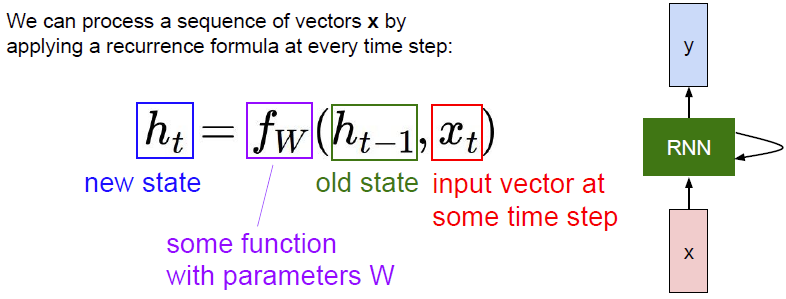
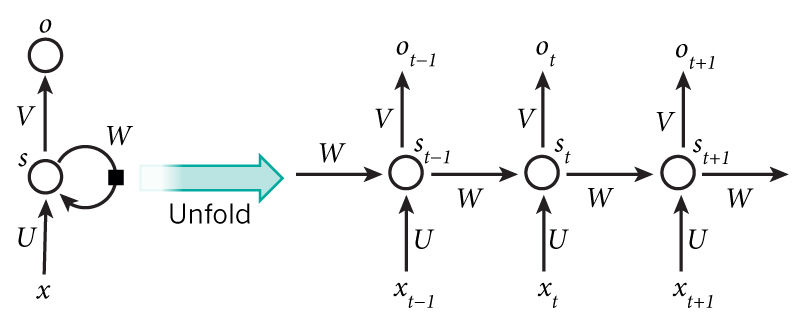
[A recurrent neural network and the unfolding in time of the computation involved in its forward computation. Source: Nature]<br>
$x_t$: input at time step $t$<br>
$s_t$: hidden state at time step $t$<br>
$o_t$: output at time step $t$<br>
$W, U, V$: weight for input, hidden state, and output<br>
$s_t = tanh(Ux_t + Ws_{t-1})$<br>
$o_t = softmax(Vs_t)$<br>


#### Implementing Vanilla RNN ( 40 points )
1. [Single timestep forward](#1) ( 10 points )
2. [Single timestep backward](#2) ( 10 points )
3. [forward pass for an entire sequence](#3) ( 10 points )
4. [backward pass for an entire sequence](#4) ( 10 points )


### Submitting your work:
<font color=red>**DO NOT clear the final outputs**</font> so that TAs can grade both your code and results.  

### Some helpful tutorials and references for assignment #3:
- [1] PyTorch official tutorials. [[link]](https://pytorch.org/tutorials/)
- [2] Stanford CS231n lectures. [[link]](http://cs231n.stanford.edu/)
- [3] http://www.wildml.com/2015/09/recurrent-neural-networks-tutorial-part-1-introduction-to-rnns/
- [4] https://ratsgo.github.io/natural%20language%20processing/2017/03/09/rnnlstm/


In [25]:
def eval_numerical_gradient_array(f, x, df, h=1e-5):
    """
    Evaluate a numeric gradient for a function that accepts a numpy
    array and returns a numpy array.
    """
    grad = np.zeros_like(x)
    it = np.nditer(x, flags=['multi_index'], op_flags=['readwrite'])
    while not it.finished:
        ix = it.multi_index

        oldval = x[ix]
        x[ix] = oldval + h
        pos = f(x).copy()
        x[ix] = oldval - h
        neg = f(x).copy()
        x[ix] = oldval

        grad[ix] = np.sum((pos - neg) * df) / (2 * h)
        it.iternext()
    return grad


def rel_error(x, y):
    """ returns relative error """
    return np.max(np.abs(x - y) / (np.maximum(1e-8, np.abs(x) + np.abs(y))))


def getdata_rnn_step_forward():
	np.random.seed(2177)

	N, D, H = 3, 5, 4
	x = np.random.randn(N, D)
	prev_h = np.random.randn(N, H)
	Wx = np.random.randn(D, H)
	Wh = np.random.randn(H, H)
	b = np.random.randn(H)

	expt_next_h = np.asarray([
		[-0.99921173, -0.99967951,  0.39127099, -0.93436299],
	 	[ 0.84348286,  0.99996526, -0.9978802,   0.99996645],
	  [-0.94481752, -0.71940178,  0.99994009, -0.64806562]])

	return x, prev_h, Wx, Wh, b, expt_next_h


def getdata_rnn_step_backward(x,h,Wx,Wh,b,dnext_h):

	fx  = lambda x: rnn_step_forward(x, h, Wx, Wh, b)[0]
	fh  = lambda prev_h: rnn_step_forward(x, h, Wx, Wh, b)[0]
	fWx = lambda Wx: rnn_step_forward(x, h, Wx, Wh, b)[0]
	fWh = lambda Wh: rnn_step_forward(x, h, Wx, Wh, b)[0]
	fb  = lambda b: rnn_step_forward(x, h, Wx, Wh, b)[0]

	dx_num = eval_numerical_gradient_array(fx, x, dnext_h)
	dprev_h_num = eval_numerical_gradient_array(fh, h, dnext_h)
	dWx_num = eval_numerical_gradient_array(fWx, Wx, dnext_h)
	dWh_num = eval_numerical_gradient_array(fWh, Wh, dnext_h)
	db_num = eval_numerical_gradient_array(fb, b, dnext_h)

	return dx_num, dprev_h_num, dWx_num, dWh_num, db_num


def getdata_rnn_forward():
	np.random.seed(2177)

	N, D, T, H = 2,3,4,5
	x = np.random.randn(N, T, D)
	h0 = np.random.randn(N, H)
	Wx = np.random.randn(D, H)
	Wh = np.random.randn(H, H)
	b = np.random.randn(H)

	expt_next_h = np.asarray([
    [[ 0.79899136, -0.90076473, -0.69325878, -0.99991011,  0.92991908],
   [-0.04474799, -0.99999994, -0.72167573, -0.99942462, -0.98397185],
   [ 0.98674954, -0.74668554, -0.30836793, -0.87580427, -0.25076433],
   [ 0.99999994,  0.46495278, -0.6291276 ,  0.44811995, -0.91013617]],

 	[[-0.57789921, -0.10875688, -0.99049558, -0.58448393,  0.76942269],
   [-0.05646372, -0.99855467, -0.827688  , -0.65262183, -0.98211725],
   [ 0.89687939,  0.99998112, -0.99999517,  0.66932722,  0.99952606],
   [-0.97608409, -0.64972242, -0.99987169, -0.99747724,  0.99962792]]])

	return x, h0, Wx, Wh, b, expt_next_h

def getdata_rnn_backward(x,h0,Wx,Wh,b,dout):
	fx = lambda x: rnn_forward(x, h0, Wx, Wh, b)[0]
	fh0 = lambda h0: rnn_forward(x, h0, Wx, Wh, b)[0]
	fWx = lambda Wx: rnn_forward(x, h0, Wx, Wh, b)[0]
	fWh = lambda Wh: rnn_forward(x, h0, Wx, Wh, b)[0]
	fb = lambda b: rnn_forward(x, h0, Wx, Wh, b)[0]

	dx_num = eval_numerical_gradient_array(fx, x, dout)
	dh0_num = eval_numerical_gradient_array(fh0, h0, dout)
	dWx_num = eval_numerical_gradient_array(fWx, Wx, dout)
	dWh_num = eval_numerical_gradient_array(fWh, Wh, dout)
	db_num = eval_numerical_gradient_array(fb, b, dout)

	return dx_num, dh0_num, dWx_num, dWh_num, db_num


## <a name="1"></a> 1,2. Vanilla RNN: step forward and backward ( 20 points )

In this section, you will implement step forward and backward passes for **a single timestep** of a vanilla recurrent neural network. Using the code provided as guidance, complete the functions `rnn_step_forward` and `rnn_step_backward`. just write the code in whatever way you find most clear.

When you are done, run the following to check your implementations.

### <a name="1"></a> 1. single timestep forward ( 10 points )

In [26]:
import numpy as np

#------------------------------------------------------
# vanilla rnn step forward
#------------------------------------------------------
def rnn_step_forward(x, prev_h, Wx, Wh, b):
    """
    Run the forward pass for a single timestep of a vanilla RNN that uses a tanh
    activation function.

    The input data has dimension D, the hidden state has dimension H, and we use
    a minibatch size of N.

    Inputs:
    - x: Input data for this timestep, of shape (N, D).
    - prev_h: Hidden state from previous timestep, of shape (N, H)
    - Wx: Weight matrix for input-to-hidden connections, of shape (D, H)
    - Wh: Weight matrix for hidden-to-hidden connections, of shape (H, H)
    - b: Biases of shape (H,)

    Returns a tuple of:
    - next_h: Next hidden state, of shape (N, H)
    - cache: Tuple of values needed for the backward pass.
    """
    next_h, cache = None, None
    ##########################################################################
    # TODO: Implement a single forward step for the vanilla RNN.                                           #
    ##########################################################################

    a = x.dot(Wx) + prev_h.dot(Wh) + b
    next_h = np.tanh(a)
    cache = (x, prev_h, Wx, Wh, next_h)
    ##########################################################################
    #                               END OF YOUR CODE                             #
    ##########################################################################
    return next_h, cache


In [27]:
#------------------------------------------------------
# rnn_step_forward 실행
# errors should be less than 1e-8
#------------------------------------------------------
x, prev_h, Wx, Wh, b, expected_next_h = getdata_rnn_step_forward()

next_h, _ = rnn_step_forward(x, prev_h, Wx, Wh, b)

print('[1/4] rnn_step_forward 검증')
err = rel_error(expected_next_h, next_h)
status = '✓ PASS' if err < 1e-8 else '✗ FAIL'
print(f'  next_h error : {err:.2e}   {status}  (threshold: 1e-8)')

[1/4] rnn_step_forward 검증
  next_h error : 2.56e-09   ✓ PASS  (threshold: 1e-8)


### <a name="1"></a> 2. single timestep backward ( 10 points )

In [28]:
#------------------------------------------------------
# vanilla rnn step backward
#------------------------------------------------------
def rnn_step_backward(dnext_h, cache):
    """
    Backward pass for a single timestep of a vanilla RNN.

    Inputs:
    - dnext_h: Gradient of loss with respect to next hidden state
    - cache: Cache object from the forward pass

    Returns a tuple of:
    - dx: Gradients of input data, of shape (N, D)
    - dprev_h: Gradients of previous hidden state, of shape (N, H)
    - dWx: Gradients of input-to-hidden weights, of shape (D, H)
    - dWh: Gradients of hidden-to-hidden weights, of shape (H, H)
    - db: Gradients of bias vector, of shape (H,)
    """
    dx, dprev_h, dWx, dWh, db = None, None, None, None, None
    ##########################################################################
    # TODO: Implement the backward pass for a single step of a vanilla RNN.      #                                                                           #
    # HINT: For the tanh function, you can compute the local derivative in terms #
    # of the output value from tanh.                                             #
    ##########################################################################

    x, prev_h, Wx, Wh, next_h = cache

    da = dnext_h * (1 - next_h ** 2)

    dx = da.dot(Wx.T)
    dprev_h = da.dot(Wh.T)
    dWx = x.T.dot(da)
    dWh = prev_h.T.dot(da)
    db = np.sum(da, axis=0)
    ##########################################################################
    #                               END OF YOUR CODE                             #
    ##########################################################################
    return dx, dprev_h, dWx, dWh, db


In [29]:
#------------------------------------------------------
# rnn_step_backward 실행
# errors should be less than 1e-8
#------------------------------------------------------
np.random.seed(2177)

x, h, Wx, Wh, b, expected_next_h = getdata_rnn_step_forward()
out, cache = rnn_step_forward(x, h, Wx, Wh, b)
dnext_h = np.random.randn(*out.shape)
dx_num, dprev_h_num, dWx_num, dWh_num, db_num = getdata_rnn_step_backward(x,h,Wx,Wh,b,dnext_h)

dx, dprev_h, dWx, dWh, db = rnn_step_backward(dnext_h, cache)

print('[2/4] rnn_step_backward 검증')
errors = {
    'dx     ': rel_error(dx_num, dx),
    'dprev_h': rel_error(dprev_h_num, dprev_h),
    'dWx    ': rel_error(dWx_num, dWx),
    'dWh    ': rel_error(dWh_num, dWh),
    'db     ': rel_error(db_num, db),
}
all_pass = True
for name, err in errors.items():
    status = '✓' if err < 1e-8 else '✗'
    if err >= 1e-8:
        all_pass = False
    print(f'  {name} error : {err:.2e}   {status}')
print(f'  → {"✓ ALL PASS" if all_pass else "✗ SOME FAILED"}  (threshold: 1e-8)')

[2/4] rnn_step_backward 검증
  dx      error : 6.11e-10   ✓
  dprev_h error : 7.70e-11   ✓
  dWx     error : 4.92e-10   ✓
  dWh     error : 1.00e-10   ✓
  db      error : 3.03e-11   ✓
  → ✓ ALL PASS  (threshold: 1e-8)


## <a name="1"></a> 3,4. Vanilla RNN: forward and backward ( 20 points )

Combining the single timestep forward and backward passes for vanilla RNN, you will implement a vanilla RNN that process **an entire sequence**. Using the code provided as guidance, complete the functions `rnn_forward` and `rnn_backward`.

When you are done, run the following to check your implementations.

### <a name="1"></a> 3. forward pass for an entire sequence ( 10 points )

In [30]:
#------------------------------------------------------
# vanilla rnn forward
#------------------------------------------------------
def rnn_forward(x, h0, Wx, Wh, b):
    """
    Run a vanilla RNN forward on an entire sequence of data. We assume an input
    sequence composed of T vectors, each of dimension D. The RNN uses a hidden
    size of H, and we work over a minibatch containing N sequences. After running
    the RNN forward, we return the hidden states for all timesteps.

    Inputs:
    - x: Input data for the entire timeseries, of shape (N, T, D).
    - h0: Initial hidden state, of shape (N, H)
    - Wx: Weight matrix for input-to-hidden connections, of shape (D, H)
    - Wh: Weight matrix for hidden-to-hidden connections, of shape (H, H)
    - b: Biases of shape (H,)

    Returns a tuple of:
    - h: Hidden states for the entire timeseries, of shape (N, T, H).
    - cache: Values needed in the backward pass
    """
    h, cache = None, None
    ##########################################################################
    # TODO: Implement forward pass for a vanilla RNN running on a sequence of    #
    # input data.                                                            #
    ##########################################################################


    N, T, D = x.shape
    H = h0.shape[1]

    h = np.zeros((N, T, H))
    cache = []

    prev_h = h0

    for t in range(T):
        next_h, cache_t = rnn_step_forward(x[:, t, :], prev_h, Wx, Wh, b)
        h[:, t, :] = next_h
        cache.append(cache_t)
        prev_h = next_h
    ##########################################################################
    #                               END OF YOUR CODE                             #
    ##########################################################################
    return h, cache


#------------------------------------------------------
# vanilla rnn backward
#------------------------------------------------------
def rnn_backward(dh, cache):
    """
    Compute the backward pass for a vanilla RNN over an entire sequence of data.

    Inputs:
    - dh: Upstream gradients of all hidden states, of shape (N, T, H)

    Returns a tuple of:
    - dx: Gradient of inputs, of shape (N, T, D)
    - dh0: Gradient of initial hidden state, of shape (N, H)
    - dWx: Gradient of input-to-hidden weights, of shape (D, H)
    - dWh: Gradient of hidden-to-hidden weights, of shape (H, H)
    - db: Gradient of biases, of shape (H,)
    """
    dx, dh0, dWx, dWh, db = None, None, None, None, None

    ##########################################################################
    # TODO: Implement the backward pass for a vanilla RNN running an entire      #
    # sequence of data. You should use the rnn_step_backward function that you   #
    # defined above.                                                             #
    ##########################################################################

    N, T, H = dh.shape

    x0, prev_h0, Wx, Wh, next_h0 = cache[0]
    D = x0.shape[1]

    dx = np.zeros((N, T, D))
    dWx = np.zeros_like(Wx)
    dWh = np.zeros_like(Wh)
    db = np.zeros(H)

    dprev_h_t = np.zeros((N, H))

    for t in reversed(range(T)):
        dcurrent_h = dh[:, t, :] + dprev_h_t

        dx_t, dprev_h_t, dWx_t, dWh_t, db_t = rnn_step_backward(
            dcurrent_h, cache[t]
        )

        dx[:, t, :] = dx_t
        dWx += dWx_t
        dWh += dWh_t
        db += db_t

    dh0 = dprev_h_t
    ##########################################################################
    #                               END OF YOUR CODE                             #
    ##########################################################################
    return dx, dh0, dWx, dWh, db



In [31]:

#------------------------------------------------------
# rnn_forward 실행
# errors should be less than 1e-7
#------------------------------------------------------

x,h0,Wx,Wh,b, expected_h = getdata_rnn_forward()

h, _ = rnn_forward(x, h0, Wx, Wh, b)

print('[3/4] rnn_forward 검증')
err = rel_error(expected_h, h)
status = '✓ PASS' if err < 1e-7 else '✗ FAIL'
print(f'  h error : {err:.2e}   {status}  (threshold: 1e-7)')

[3/4] rnn_forward 검증
  h error : 2.10e-08   ✓ PASS  (threshold: 1e-7)


### <a name="1"></a> 4. backward pass for an entire sequence ( 10 points )

In [32]:
#------------------------------------------------------
# rnn_backward 실행
# errors should be less than 1e-7
#------------------------------------------------------

np.random.seed(2177)

x,h0,Wx,Wh,b, expected_h = getdata_rnn_forward()
out, cache = rnn_forward(x, h0, Wx, Wh, b)
dout = np.random.randn(*out.shape)
dx_num, dh0_num, dWx_num, dWh_num, db_num = getdata_rnn_backward(x,h0,Wx,Wh,b,dout)

dx, dh0, dWx, dWh, db = rnn_backward(dout, cache)

print('[4/4] rnn_backward 검증')
errors = {
    'dx ': rel_error(dx_num, dx),
    'dh0': rel_error(dh0_num, dh0),
    'dWx': rel_error(dWx_num, dWx),
    'dWh': rel_error(dWh_num, dWh),
    'db ': rel_error(db_num, db),
}
all_pass = True
for name, err in errors.items():
    status = '✓' if err < 1e-7 else '✗'
    if err >= 1e-7:
        all_pass = False
    print(f'  {name} error : {err:.2e}   {status}')
print(f'  → {"✓ ALL PASS" if all_pass else "✗ SOME FAILED"}  (threshold: 1e-7)')

[4/4] rnn_backward 검증
  dx  error : 1.91e-08   ✓
  dh0 error : 7.20e-10   ✓
  dWx error : 1.34e-10   ✓
  dWh error : 5.67e-09   ✓
  db  error : 8.44e-10   ✓
  → ✓ ALL PASS  (threshold: 1e-7)
